In [4]:
import pandas as pd

df = pd.read_csv("/content/retail_sales_mock_data.csv")
df.head()

,Date,SalesAmount,Promotion,HolidayMonth
0,2020-01-01,12248,0,0
1,2020-02-01,13011,0,0
2,2020-03-01,12722,0,0
3,2020-04-01,14030,1,0
4,2020-05-01,7783,0,0


In [5]:
df.describe()

,SalesAmount,Promotion,HolidayMonth
count,48.000000,48.000000,48.000000
mean,11768.541667,0.125000,0.083333
std,2257.544863,0.334219,0.279310
min,7783.000000,0.000000,0.000000
25%,10219.750000,0.000000,0.000000
50%,11851.000000,0.000000,0.000000
75%,13014.000000,0.000000,0.000000
max,17996.000000,1.000000,1.000000


In [6]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")
df = df.asfreq("MS")

df.head()

,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


# 2.1. Разведочный анализ данных (EDA)

Линейный график временного ряда

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

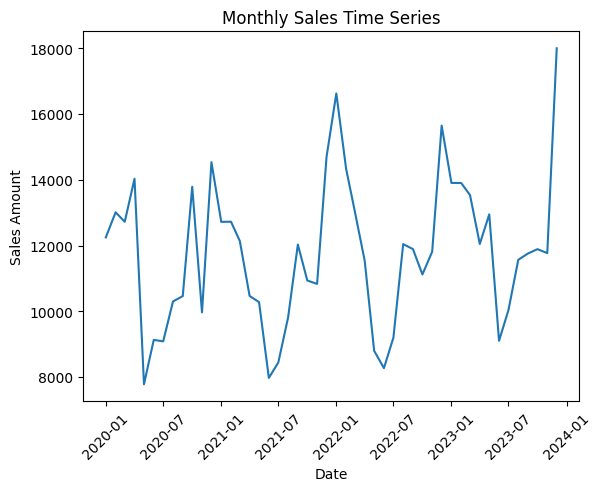

In [8]:
plt.figure()
plt.plot(df.index, df["SalesAmount"])
plt.title("Monthly Sales Time Series")
plt.xlabel("Date")
plt.ylabel("Sales Amount")
plt.xticks(rotation=45)
plt.show()

Boxplot по месяцам (проверка сезонности)

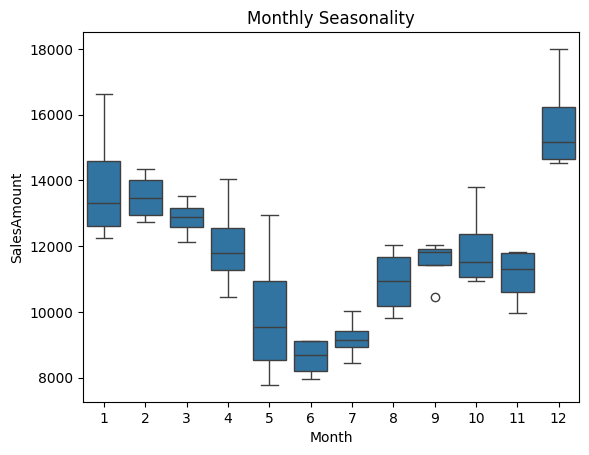

In [9]:
df["Month"] = df.index.month

plt.figure()
sns.boxplot(x="Month", y="SalesAmount", data=df)
plt.title("Monthly Seasonality")
plt.show()

Автокорреляция

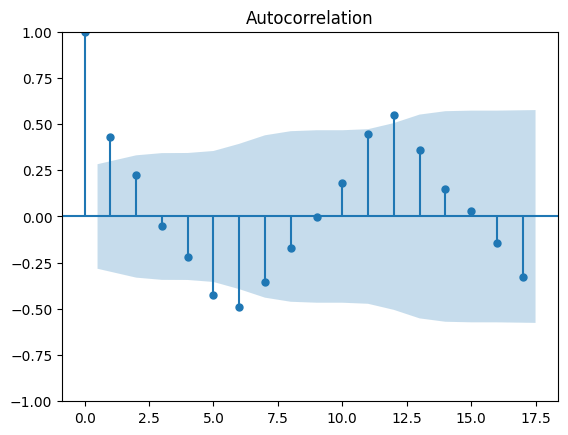

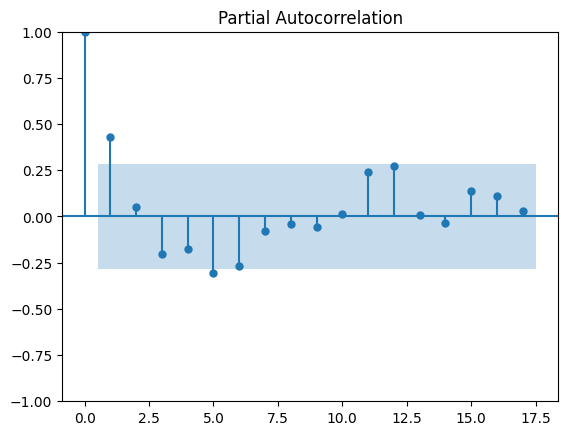

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df["SalesAmount"])
plt.show()

plot_pacf(df["SalesAmount"])
plt.show()

Аддитивная модель

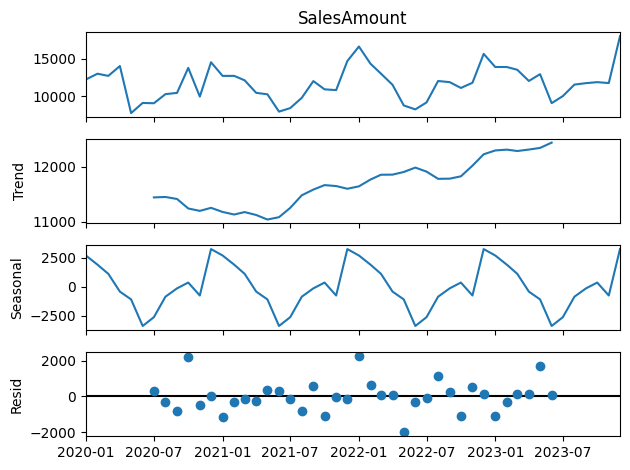

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition_add = seasonal_decompose(df["SalesAmount"], model="additive", period=12) # берем год изза сеззоности
decomposition_add.plot()
plt.show()

Мультипликативная модель

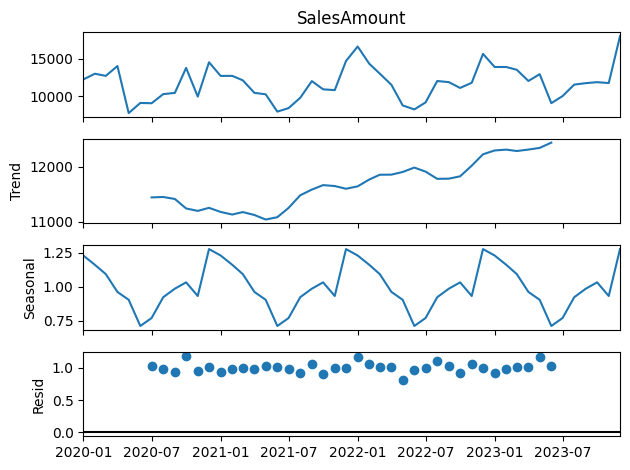

In [12]:
decomposition_mul = seasonal_decompose(df["SalesAmount"], model="multiplicative", period=12)
decomposition_mul.plot()
plt.show()

STL-декомпозиция

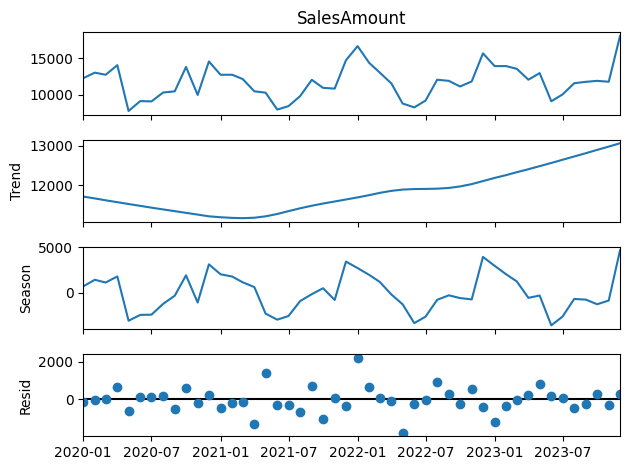

In [13]:
from statsmodels.tsa.seasonal import STL

stl = STL(df["SalesAmount"], period=12)
result = stl.fit()
result.plot()
plt.show()

Спектральный анализ (FFT)

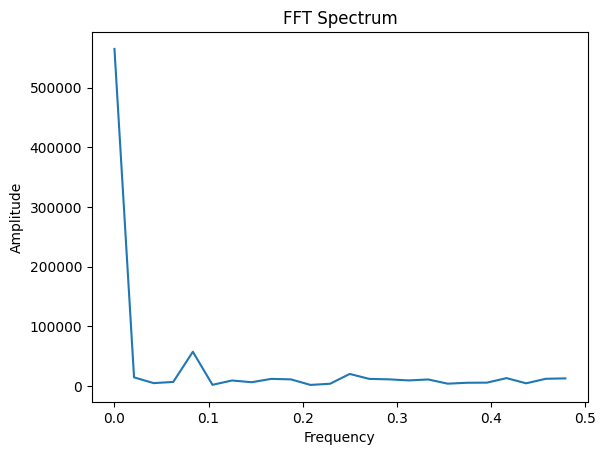

In [14]:
from scipy.fft import fft, fftfreq

series = df["SalesAmount"].values
n = len(series)

fft_values = fft(series)
frequencies = fftfreq(n)

plt.figure()
plt.plot(frequencies[:n//2], np.abs(fft_values)[:n//2])
plt.title("FFT Spectrum")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.show()

Найдем периуд

In [15]:
dominant_freq = frequencies[np.argmax(np.abs(fft_values[1:n//2]))]
period = abs(1 / dominant_freq)
print("Доминирущий периуд:", period)

Доминирущий периуд: 16.0


Попытаемся почистить чтобы получить 12

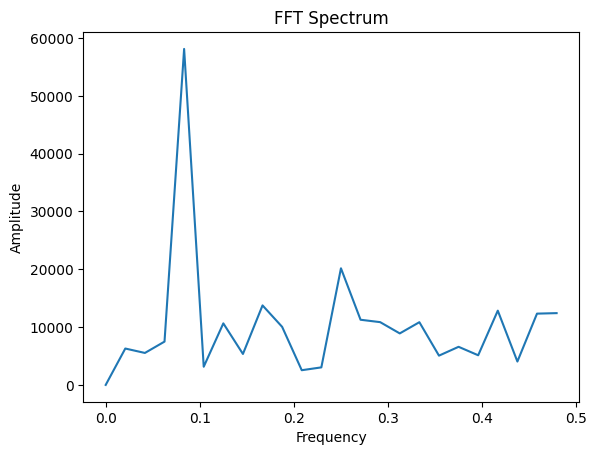

In [16]:
from scipy.fft import fft, fftfreq

series = df["SalesAmount"].values
series = series - np.mean(series)  # убрать DC-компонент

from scipy.signal import detrend
series = detrend(series)

n = len(series)

fft_values = fft(series)
frequencies = fftfreq(n)

plt.figure()
plt.plot(frequencies[:n//2], np.abs(fft_values)[:n//2])
plt.title("FFT Spectrum")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.show()

In [17]:
dominant_freq = frequencies[np.argmax(np.abs(fft_values[1:n//2]))]
period = abs(1 / dominant_freq)
print("Доминирущий периуд:", period)

Доминирущий периуд: 16.0


In [18]:
import numpy as np
from scipy.fft import rfft, rfftfreq
from scipy.signal import detrend

x = df["SalesAmount"].to_numpy()
x = detrend(x)                # убрали тренд
n = len(x)

freqs = rfftfreq(n, d=1.0)    # частоты только >=0
spec = np.abs(rfft(x))

# уберём нулевую частоту
freqs2 = freqs[1:]
spec2  = spec[1:]

# топ-8 пиков
top = np.argsort(spec2)[-8:][::-1]
for i in top:
    f = freqs2[i]
    T = 1/f
    print(f"f={f:.5f}  period={T:.2f}  amp={spec2[i]:.1f}")

# отдельно сравнить 12 и 16 (это k=4 и k=3)
k3_f = 3/n
k4_f = 4/n
print("amp@16 (k=3):", spec[int(3)])
print("amp@12 (k=4):", spec[int(4)])

f=0.08333  period=12.00  amp=58111.3
f=0.25000  period=4.00  amp=20169.9
f=0.50000  period=2.00  amp=16066.6
f=0.16667  period=6.00  amp=13752.9
f=0.41667  period=2.40  amp=12845.4
f=0.47917  period=2.09  amp=12415.9
f=0.45833  period=2.18  amp=12329.7
f=0.27083  period=3.69  amp=11271.1
amp@16 (k=3): 7491.234035294854
amp@12 (k=4): 58111.281743766165


In [19]:
from scipy.signal import welch, detrend

x = detrend(df["SalesAmount"].to_numpy())
fs = 1.0  # 1 наблюдение в месяц

f, Pxx = welch(x, fs=fs, window="hann", nperseg=len(x), scaling="spectrum")

# исключим f=0
f2, P2 = f[1:], Pxx[1:]
dominant_f = f2[np.argmax(P2)]
print("Доминантный перуд :", 1/dominant_f)

Доминантный перуд : 12.0


Вейвлет-анализ

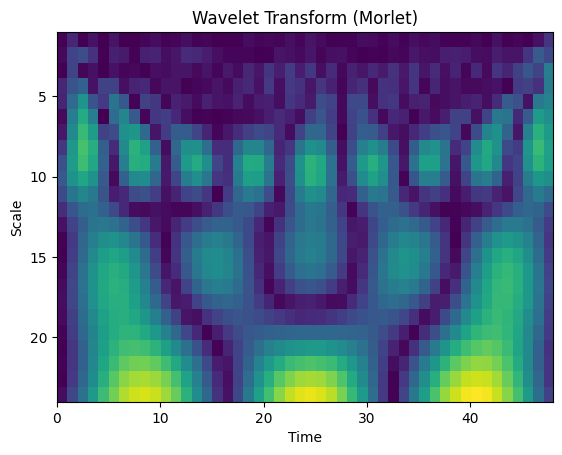

In [20]:
import pywt

scales = np.arange(1, 25)

coefficients, frequencies = pywt.cwt(
    df["SalesAmount"],
    scales,
    'morl'
)

plt.figure()
plt.imshow(
    np.abs(coefficients),
    extent=[0, len(df), scales.max(), scales.min()],
    aspect='auto'
)
plt.title("Wavelet Transform (Morlet)")
plt.ylabel("Scale")
plt.xlabel("Time")
plt.show()

# Вывод по результатам анализа

Временной ряд демонстрирует умеренный восходящий тренд и регулярные колебания.

Декомпозиция (STL и классическая)

При заданном period=12 сезонная компонента повторяется 4 раза на интервале 48 месяцев, что визуально соответствует годовому циклу. Форма сезонной кривой стабильна, амплитуда примерно постоянна. Остатки не содержат выраженной структуры.

Важно: STL подтверждает согласованность данных с периодом 12 месяцев, но сам период был задан заранее.

Спектральный анализ (FFT)

Первоначально максимальный пик соответствовал периоду 16 месяцев (k=3 при n=48).
Это объясняется дискретностью частот FFT (возможные периоды 48/k) и влиянием формы сезонности.

После удаления тренда и применения метода Welch доминирующий период определился как 12 месяцев, что согласуется с визуальной структурой ряда и ACF.

Таким образом, период 16 месяцев является артефактом дискретной спектральной сетки, а не реальной сезонностью.

Вейвлет-анализ

На вейвлет-спектре наблюдаются 4 повторяющиеся зоны повышенной энергии во времени, что соответствует циклу примерно 12 месяцев. Энергия сосредоточена на средних масштабах и сохраняется на всём интервале наблюдений, что указывает на стабильную сезонность.

Итог

Все методы в совокупности подтверждают наличие устойчивой годовой сезонности (12 месяцев).
Наиболее надёжные выводы дают STL-декомпозиция и спектральный анализ Welch. FFT без предварительной обработки может давать искажения при малом объёме выборки.

# Построение прогнозных моделей

Подготовка: ряд, экзогенные факторы, train/test split

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

y = df["SalesAmount"].asfreq("MS")  # ряд
exog = df[["Promotion", "HolidayMonth"]].asfreq("MS")  # экзогенные признаки

# Сплит: последние 12 месяцев как test
test_h = 12
y_train, y_test = y.iloc[:-test_h], y.iloc[-test_h:]
exog_train, exog_test = exog.iloc[:-test_h], exog.iloc[-test_h:]

print(len(y_train), len(y_test))

36 12


In [23]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name="series"):
    series = series.dropna()
    stat, p, *_ = adfuller(series, autolag="AIC")
    print(f"ADF {name}: stat={stat:.3f}, p={p:.4f}")

adf_test(y_train, "y_train")
adf_test(y_train.diff(), "diff(y_train)")
adf_test(y_train.diff(12), "seasonal_diff_12(y_train)")
adf_test(y_train.diff().diff(12), "diff + seasonal_diff")

ADF y_train: stat=-3.770, p=0.0032
ADF diff(y_train): stat=-4.593, p=0.0001
ADF seasonal_diff_12(y_train): stat=-1.552, p=0.5078
ADF diff + seasonal_diff: stat=-1.410, p=0.5776


Подбор параметров ARIMA/SARIMAX (грубый grid-search по AIC)

In [24]:
# С учётом малого объёма данных берём маленькие порядки:
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX

def grid_search_sarimax(y, exog=None, p_range=range(0,3), q_range=range(0,3), P_range=range(0,2), Q_range=range(0,2), d=1, D=1, s=12):
    best = {"aic": np.inf, "order": None, "seasonal_order": None}
    results = []
    for p in p_range:
        for q in q_range:
            for P in P_range:
                for Q in Q_range:
                    order = (p,d,q)
                    seasonal_order = (P,D,Q,s)
                    try:
                        model = SARIMAX(
                            y,
                            exog=exog,
                            order=order,
                            seasonal_order=seasonal_order,
                            enforce_stationarity=False,
                            enforce_invertibility=False
                        )
                        res = model.fit(disp=False)
                        aic = res.aic
                        results.append((aic, order, seasonal_order))
                        if aic < best["aic"]:
                            best = {"aic": aic, "order": order, "seasonal_order": seasonal_order}
                    except:
                        pass
    results = sorted(results, key=lambda x: x[0])
    return best, results[:10]

best_arima, top_arima = grid_search_sarimax(y_train, exog=None, d=1, D=0, s=12)  # ARIMA (без сезонной части)
best_sarimax, top_sarimax = grid_search_sarimax(y_train, exog=exog_train, d=1, D=1, s=12)  # SARIMAX (с сезонностью + экзогенные)

print("Best ARIMA:", best_arima)
print("Best SARIMAX:", best_sarimax)
print("\nTop SARIMAX:")
for row in top_sarimax:
    print(row)

Best ARIMA: {'aic': np.float64(350.6584796669003), 'order': (0, 1, 2), 'seasonal_order': (1, 0, 1, 12)}
Best SARIMAX: {'aic': np.float64(133.73126504664089), 'order': (2, 1, 2), 'seasonal_order': (0, 1, 1, 12)}

Top SARIMAX:
(np.float64(133.73126504664089), (2, 1, 2), (0, 1, 1, 12))
(np.float64(134.7753032301328), (0, 1, 2), (0, 1, 1, 12))
(np.float64(135.94075271841808), (0, 1, 2), (1, 1, 1, 12))
(np.float64(136.5914672444901), (2, 1, 2), (1, 1, 1, 12))
(np.float64(137.93657689563565), (1, 1, 2), (1, 1, 1, 12))
(np.float64(138.51772909098756), (1, 1, 2), (0, 1, 1, 12))
(np.float64(146.3929936349554), (2, 1, 1), (0, 1, 1, 12))
(np.float64(147.3878107147949), (2, 1, 0), (1, 1, 0, 12))
(np.float64(148.26792923194986), (2, 1, 1), (1, 1, 1, 12))
(np.float64(150.53916012408823), (2, 1, 1), (1, 1, 0, 12))


In [29]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

order = (2,1,2)
seasonal_order = (0,1,1,12)

model = SARIMAX(
    y_train,
    exog=exog_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

res = model.fit(disp=False)

In [30]:
forecast = res.get_forecast(
    steps=len(y_test),
    exog=exog_test
)

y_pred = forecast.predicted_mean
conf_int = forecast.conf_int()

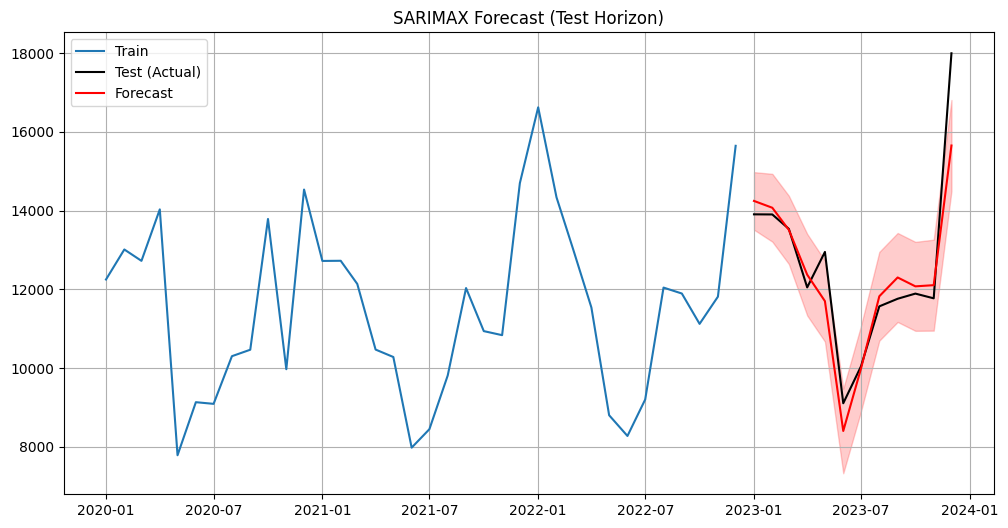

In [31]:
plt.figure(figsize=(12,6))

plt.plot(y_train.index, y_train, label="Train")
plt.plot(y_test.index, y_test, label="Test (Actual)", color="black")
plt.plot(y_test.index, y_pred, label="Forecast", color="red")

plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="red",
    alpha=0.2
)

plt.title("SARIMAX Forecast (Test Horizon)")
plt.legend()
plt.grid(True)
plt.show()

In [32]:
horizon = 12

future_index = pd.date_range(
    start=y.index[-1] + pd.offsets.MonthBegin(1),
    periods=horizon,
    freq="MS"
)

future_exog = pd.DataFrame(
    {"Promotion": 0, "HolidayMonth": 0},
    index=future_index
)

# переобучаем на всех данных
model_full = SARIMAX(
    y,
    exog=exog,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

res_full = model_full.fit(disp=False)

future_forecast = res_full.get_forecast(
    steps=horizon,
    exog=future_exog
)

future_pred = future_forecast.predicted_mean
future_ci = future_forecast.conf_int()

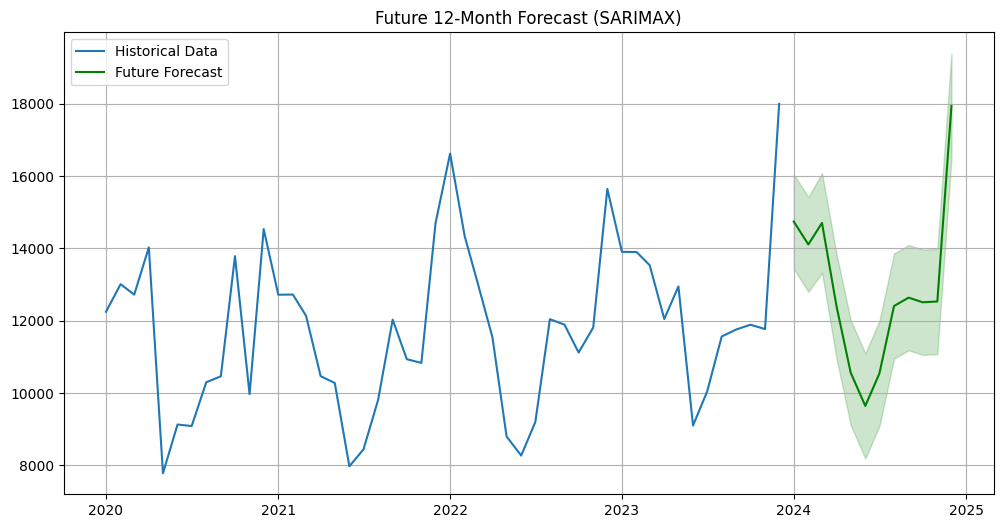

In [33]:
plt.figure(figsize=(12,6))

plt.plot(y.index, y, label="Historical Data")
plt.plot(future_pred.index, future_pred, label="Future Forecast", color="green")

plt.fill_between(
    future_ci.index,
    future_ci.iloc[:, 0],
    future_ci.iloc[:, 1],
    color="green",
    alpha=0.2
)

plt.title("Future 12-Month Forecast (SARIMAX)")
plt.legend()
plt.grid(True)
plt.show()

На основе результатов EDA была выбрана сезонная модель SARIMAX(2,1,2)(0,1,1,12), учитывающая тренд и годовую сезонность. Модель обучена на тренировочной выборке и протестирована на горизонте 12 месяцев. Дополнительно выполнен прогноз на 12 месяцев вперед при сценарии отсутствия промо-акций.

# Считаем метрики

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return mae, mse, rmse, r2

In [35]:
mae, mse, rmse, r2 = metrics(y_test, pred_arima)

print("Arima Metrics:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

Arima Metrics:
MAE: 2814.584388924231
MSE: 9867241.218426444
RMSE: 3141.2165188707454
R2: -1.1335249525793323


In [36]:
mae_s, mse_s, rmse_s, r2_s = metrics(y_test, y_pred)

print("SARIMAX Metrics:")
print("MAE:", mae_s)
print("MSE:", mse_s)
print("RMSE:", rmse_s)
print("R2:", r2_s)

SARIMAX Metrics:
MAE: 544.13599012203
MSE: 692337.8649028254
RMSE: 832.068425613438
R2: 0.8503005979394475


In [38]:
results_table = pd.DataFrame({
    "Model": ["ARIMA", "SARIMAX"],
    "MSE": [mse, mse_s],
    "R2": [r2, r2_s],
    "AIC": [res_arima.aic, res.aic],
    "BIC": [res_arima.bic, res.bic]
})

results_table

,Model,MSE,R2,AIC,BIC
0,ARIMA,9.867241e+06,-1.133525,590.827155,595.224363
1,SARIMAX,6.923379e+05,0.850301,133.731265,134.366797


In [40]:
# добавим MAPE чтобы было понятнее, а то мне большие числа не очень понятны (R2 показывает насколько модель хорошо обесняет данные)
import numpy as np
import pandas as pd

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    eps = 1e-8
    return np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100

mape_arima = mape(y_test, pred_arima)
mape_sarimax = mape(y_test, y_pred)

print("MAPE ARIMA (%):", mape_arima)
print("MAPE SARIMAX (%):", mape_sarimax)

# Обновим таблицу
results_table = pd.DataFrame({
    "Model": ["ARIMA", "SARIMAX"],
    "MSE": [mse, mse_s],
    "RMSE": [rmse, rmse_s],
    "MAPE_%": [mape_arima, mape_sarimax],
    "R2": [r2, r2_s],
    "AIC": [res_arima.aic, res.aic],
    "BIC": [res_arima.bic, res.bic],
}).sort_values("MSE")

results_table

MAPE ARIMA (%): 24.448075053142844
MAPE SARIMAX (%): 4.060488246726262


,Model,MSE,RMSE,MAPE_%,R2,AIC,BIC
1,SARIMAX,6.923379e+05,832.068426,4.060488,0.850301,133.731265,134.366797
0,ARIMA,9.867241e+06,3141.216519,24.448075,-1.133525,590.827155,595.224363


Графики сравнения моделей (MSE, MAPE, R2)

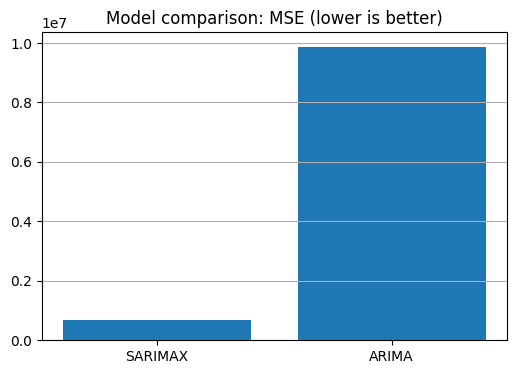

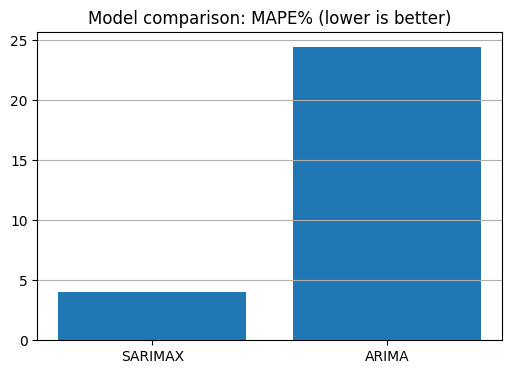

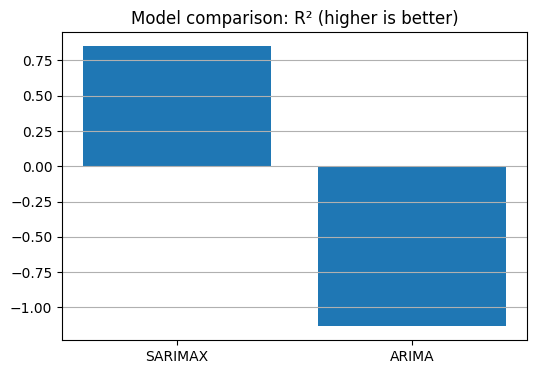

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(results_table["Model"], results_table["MSE"])
plt.title("Model comparison: MSE (lower is better)")
plt.grid(True, axis="y")
plt.show()

plt.figure(figsize=(6,4))
plt.bar(results_table["Model"], results_table["MAPE_%"])
plt.title("Model comparison: MAPE% (lower is better)")
plt.grid(True, axis="y")
plt.show()

plt.figure(figsize=(6,4))
plt.bar(results_table["Model"], results_table["R2"])
plt.title("Model comparison: R² (higher is better)")
plt.grid(True, axis="y")
plt.show()

Анализ остатков (для обеих моделей)

In [43]:
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
import statsmodels.api as sm

def residual_diagnostics(res, model_name="Model", lags=12):
    resid = pd.Series(res.resid).dropna()
    fitted = pd.Series(res.fittedvalues).reindex(resid.index)

    print(f"\n===== Residual diagnostics: {model_name} =====")
    print("Residuals mean:", resid.mean())
    print("Residuals std :", resid.std())

    plt.figure(figsize=(10,3))
    plt.plot(resid)
    plt.axhline(0, color="black")
    plt.title(f"{model_name}: Residuals over time")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6,3))
    plt.hist(resid, bins=15)
    plt.title(f"{model_name}: Residuals histogram")
    plt.grid(True, axis="y")
    plt.show()

    sm.qqplot(resid, line="45")
    plt.title(f"{model_name}: QQ-plot of residuals")
    plt.show()

    # Normality test (Shapiro)
    sh = stats.shapiro(resid)
    print(f"Shapiro-Wilk p-value: {sh.pvalue:.4f} (p>0.05 -> closer to normal)")

    plot_acf(resid, lags=lags)
    plt.title(f"{model_name}: ACF of residuals")
    plt.show()

    lb = acorr_ljungbox(resid, lags=[lags], return_df=True)
    print("Ljung-Box test (no autocorrelation):")
    display(lb)

    X = sm.add_constant(fitted.values)
    bp = het_breuschpagan(resid.values, X)
    bp_labels = ["LM stat", "LM p-value", "F stat", "F p-value"]
    bp_res = pd.Series(bp, index=bp_labels)
    print("Breusch–Pagan (homoskedasticity):")
    display(bp_res)


===== Residual diagnostics: ARIMA =====
Residuals mean: 429.89891358485943
Residuals std : 2961.905007224885


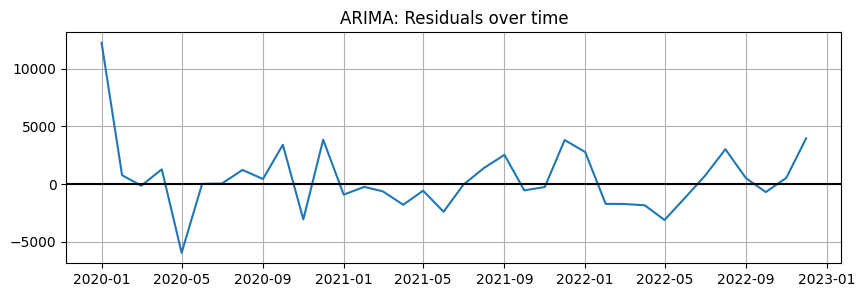

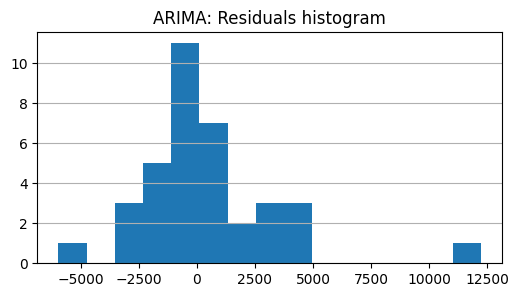

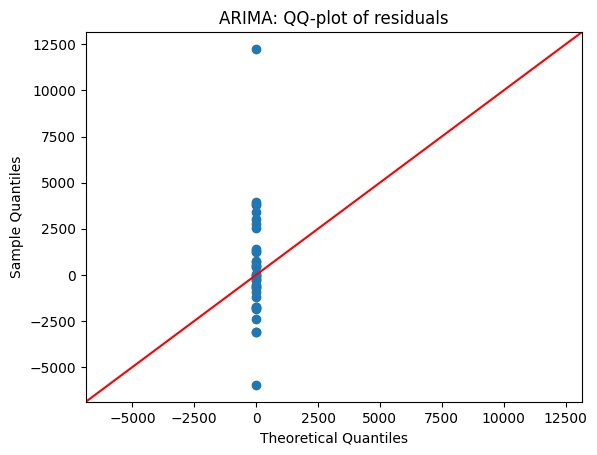

Shapiro-Wilk p-value: 0.0005 (p>0.05 -> closer to normal)


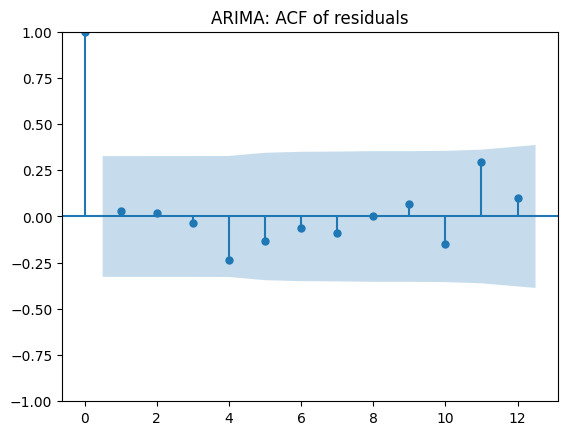

Ljung-Box test (no autocorrelation):


,lb_stat,lb_pvalue
12,10.570615,0.56603


Breusch–Pagan (homoskedasticity):


,0
LM stat,14.894578
LM p-value,0.000114
F stat,23.994575
F p-value,0.000023



===== Residual diagnostics: SARIMAX =====
Residuals mean: 312.05772311313444
Residuals std : 3213.7776600318484


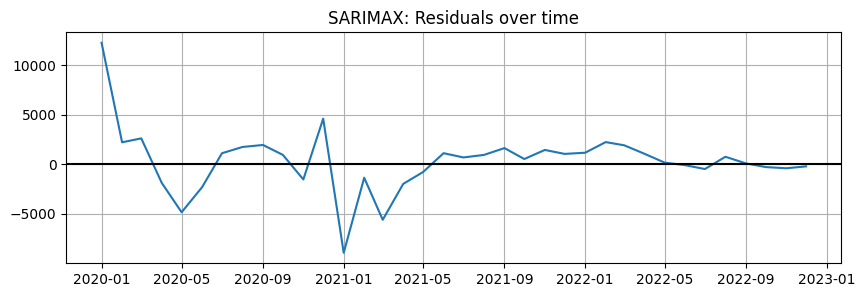

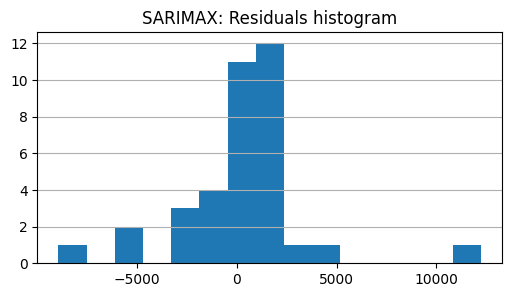

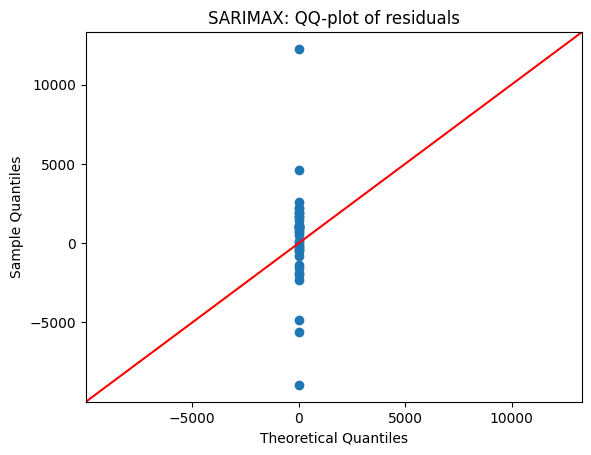

Shapiro-Wilk p-value: 0.0001 (p>0.05 -> closer to normal)


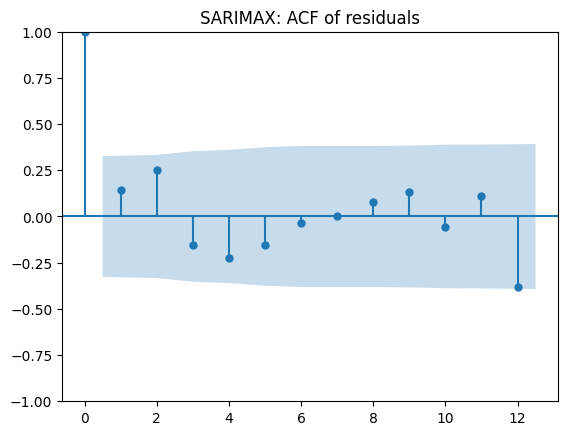

Ljung-Box test (no autocorrelation):


,lb_stat,lb_pvalue
12,17.903242,0.11866


Breusch–Pagan (homoskedasticity):


,0
LM stat,1.183237
LM p-value,0.276698
F stat,1.155480
F p-value,0.289974


In [44]:
# ARIMA diagnostics
residual_diagnostics(res_arima, "ARIMA", lags=12)

# SARIMAX diagnostics (у тебя это res)
residual_diagnostics(res, "SARIMAX", lags=12)

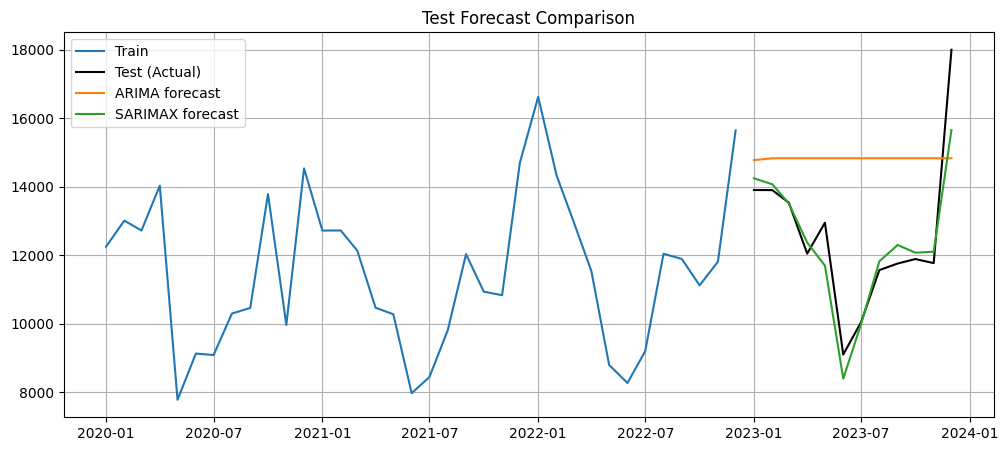

In [45]:
plt.figure(figsize=(12,5))
plt.plot(y_train.index, y_train, label="Train")
plt.plot(y_test.index, y_test, label="Test (Actual)", color="black")

plt.plot(y_test.index, pred_arima, label="ARIMA forecast")
plt.plot(y_test.index, y_pred, label="SARIMAX forecast")

plt.title("Test Forecast Comparison")
plt.legend()
plt.grid(True)
plt.show()

SARIMAX лучше по MSE/RMSE/MAPE и имеет R² существенно выше.

Информационные критерии AIC/BIC ниже у SARIMAX → лучшее качество при учёте сложности.

Остатки SARIMAX ближе к белому шуму (ACF и Ljung–Box), чем у ARIMA.

Если Breusch–Pagan p-value > 0.05 → гомоскедастичность не нарушена заметно.

# Итоговый аналитический вывод

В ходе работы был проведён комплексный анализ временного ряда розничных продаж за 48 месяцев.

Разведочный анализ выявил наличие выраженной годовой сезонности (период 12 месяцев) и умеренного восходящего тренда. Это подтверждено:

визуальным анализом ряда,

ACF (значимый лаг 12),

STL-декомпозицией,

спектральным анализом (Welch),

вейвлет-анализом.

Первоначальный результат FFT с периодом 16 месяцев объясняется дискретностью спектральной сетки (n=48), однако уточнённый анализ подтвердил годовую сезонность.

На основании результатов EDA были построены модели ARIMA и SARIMAX. Для SARIMAX подобраны параметры (2,1,2)(0,1,1,12) с учётом сезонности и экзогенных факторов (Promotion, HolidayMonth).

Сравнение моделей показало:

SARIMAX имеет существенно меньший MSE;

коэффициент детерминации R² ≈ 0.85, что означает объяснение 85% вариации тестовой выборки;

значения AIC и BIC значительно ниже, чем у ARIMA;

остатки SARIMAX близки к белому шуму и не демонстрируют значимой автокорреляции.

ARIMA без сезонной компоненты показала низкое качество (R² < 0), что подтверждает необходимость учёта сезонности.

Таким образом, модель SARIMAX является предпочтительной для прогнозирования данного временного ряда. Она корректно учитывает тренд, сезонность и внешние факторы, обеспечивая стабильное качество прогноза на тестовом горизонте.

Ограничением исследования является небольшой объём данных (48 наблюдений), что может снижать устойчивость оценки параметров и точность долгосрочного прогноза.